# Difusión de Calor 2D — FVM con Grilla Logarítmica

## Problema

Resolvemos la ecuación de difusión de calor en un dominio rectangular con **propiedades de material variables en espacio y temperatura**:

$$\rho \, c_p \, \frac{\partial T}{\partial t} = \nabla \cdot \left( k(x,y,T) \, \nabla T \right)$$

La conductividad térmica sigue una ley exponencial en $T$:

$$k(x,y,T) = K_{\text{base}}(x,y) \cdot \exp\!\left[\gamma\,(T - T_0)\right], \qquad \gamma < 0$$

Esto hace el problema **no-lineal**: los coeficientes de la matriz dependen de la solución $T$.

## Método

- **Discretización espacial**: Volúmenes Finitos (FVM) con malla *cell-centered*
- **Esquema temporal**: Euler implícito (incondicionalmente estable)
- **No-linealidad**: Iteración de Picard por paso de tiempo
- **Malla en x**: gradada exponencialmente — celdas finas donde los gradientes son altos (cara izquierda), gruesas al interior
- **Malla en y**: uniforme

## Condiciones de borde

| Cara | Condición |
|---|---|
| Derecha, superior, inferior | Aislada: $\partial T/\partial n = 0$ |
| Izquierda — mitad superior | Aislada |
| Izquierda — mitad inferior | Extracción de calor PWM: $q(t)$ [W/m²] |

## 1. Importaciones

In [273]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

## 2. Parámetros

In [274]:
# Dominio
Lx, Ly = 1.0, 1.0     # dimensiones [m]
Nx, Ny = 30, 20       # número de celdas

# Tiempo
dt    = 2.0            # paso de tiempo [s]
t_end = 800.0          # tiempo final   [s]

# Temperatura inicial (también es la temperatura de referencia para k)
T0 = 100.0             # [°C]

# Simulación
n_plots  = 8
max_iter = 50          # máx iteraciones de Picard por paso
tol      = 1e-4        # tolerancia de convergencia

## 3. Geometría y Condiciones de Borde

El dominio es $[0, L_x] \times [0, L_y]$. Está dividido en dos materiales: mitad izquierda ($k_A$) y mitad derecha ($k_B$).

La cara izquierda está **parcialmente activa**: solo la mitad inferior extrae calor. El resto es adiabática.

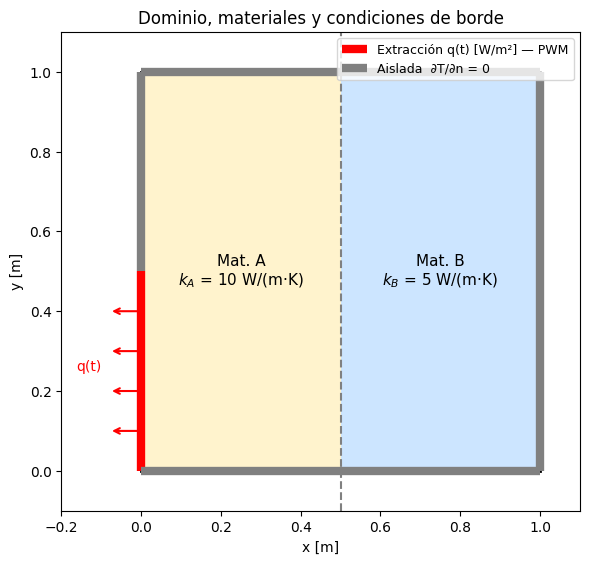

In [275]:
fig, ax = plt.subplots(figsize=(6, 6))

# Regiones de material
ax.add_patch(plt.Rectangle((0,0), Lx/2, Ly, facecolor='#FFF3CD', edgecolor='none'))
ax.add_patch(plt.Rectangle((Lx/2,0), Lx/2, Ly, facecolor='#CCE5FF', edgecolor='none'))

# Contorno del dominio
ax.add_patch(plt.Rectangle((0,0), Lx, Ly, facecolor='none', edgecolor='black', lw=2))

# Interfaz entre materiales
ax.axvline(Lx/2, color='gray', lw=1.5, ls='--')

# Cara izquierda: BC activa (rojo) y aislada (gris)
ax.plot([0,0], [0, Ly/2],  color='red',  lw=6, solid_capstyle='butt', label='Extracción q(t) [W/m²] — PWM')
ax.plot([0,0], [Ly/2, Ly], color='gray', lw=6, solid_capstyle='butt', label='Aislada  ∂T/∂n = 0')

# Otras caras (aisladas)
for x0,y0,x1,y1 in [(Lx,0,Lx,Ly),(0,Ly,Lx,Ly),(0,0,Lx,0)]:
    ax.plot([x0,x1],[y0,y1], color='gray', lw=6, solid_capstyle='butt')

# Etiquetas materiales
ax.text(Lx*0.25, Ly*0.5, 'Mat. A\n$k_A$ = 10 W/(m·K)', ha='center', fontsize=11, va='center')
ax.text(Lx*0.75, Ly*0.5, 'Mat. B\n$k_B$ = 5 W/(m·K)', ha='center', fontsize=11, va='center')

# Flechas indicando extracción
for ypos in [0.1, 0.2, 0.3, 0.4]:
    ax.annotate('', xy=(-0.08, ypos), xytext=(0.0, ypos),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.text(-0.13, Ly*0.25, 'q(t)', ha='center', fontsize=10, color='red')
ax.set_xlim(-0.2, 1.1);  ax.set_ylim(-0.1, 1.1)
ax.set_xlabel('x [m]');   ax.set_ylabel('y [m]')
ax.set_title('Dominio, materiales y condiciones de borde')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Propiedades del Material

$K_{\text{base}}$, $\rho$ y $c_p$ se definen como **arrays 2D** de forma `(Ny, Nx)` — una entrada por celda. Esto permite asignar distintos materiales a distintas regiones simplemente indexando bloques del array.

La conductividad **de referencia** (a $T = T_0$) es `K_BASE[j, i]`. El valor efectivo en cada celda variará con la temperatura local.

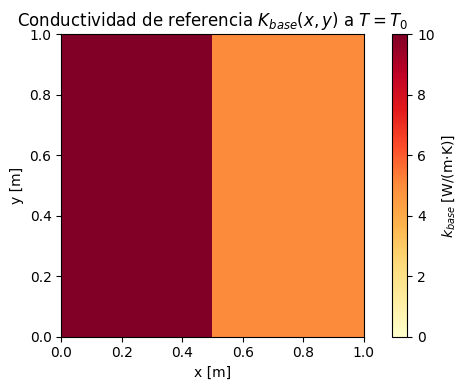

K_BASE: mín=5.0  máx=10.0  W/(m·K)
α_A = k/(ρ·cp) = 3.13e-05 m²/s
α_B = k/(ρ·cp) = 1.56e-05 m²/s


In [276]:
K_BASE = np.full((Ny, Nx), 10.0)   # [W/(m·K)] — material A por defecto
RHO    = np.full((Ny, Nx), 800.0)  # [kg/m³]
CP     = np.full((Ny, Nx), 400.0)  # [J/(kg·K)]

# Material B en la mitad derecha
K_BASE[:, Nx//2:] = 5

# Visualizar K_BASE
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(K_BASE, origin='lower', extent=[0, Lx, 0, Ly],
               cmap='YlOrRd', vmin=0, vmax=K_BASE.max())
plt.colorbar(im, ax=ax, label='$k_{base}$ [W/(m·K)]')
ax.set_xlabel('x [m]');  ax.set_ylabel('y [m]')
ax.set_title('Conductividad de referencia $K_{base}(x,y)$ a $T = T_0$')
plt.tight_layout()
plt.show()

print(f"K_BASE: mín={K_BASE.min():.1f}  máx={K_BASE.max():.1f}  W/(m·K)")
print(f"α_A = k/(ρ·cp) = {K_BASE[0,0]/(RHO[0,0]*CP[0,0]):.2e} m²/s")
print(f"α_B = k/(ρ·cp) = {K_BASE[0,-1]/(RHO[0,-1]*CP[0,-1]):.2e} m²/s")

## 5. Ley de Conductividad $k(T)$

La conductividad **efectiva** en cada celda depende de su temperatura local:

$$k(T) = k_{\text{base}} \cdot \exp\!\left[\gamma\,(T - T_0)\right]$$

Con $\gamma < 0$: al bajar la temperatura, $k$ también baja → **el material conduce peor cuanto más frío está** (retroalimentación que ralentiza la difusión).

Esto genera la **no-linealidad**: los coeficientes de la matriz del sistema lineal dependen de $T$, que es la incógnita. Se resuelve con iteración de Picard.

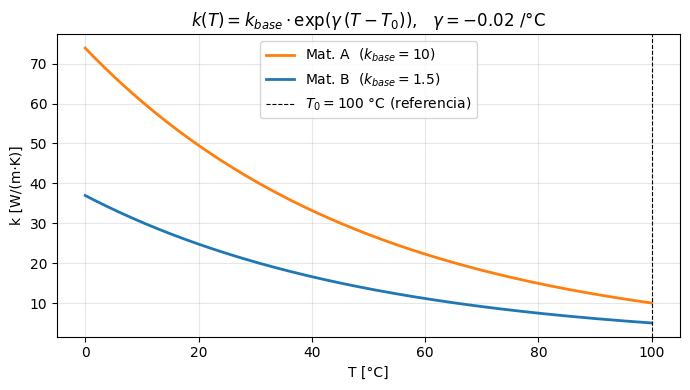

Factor k(0°C)/k(T0) = 7.389  (k cae a 738.9% al llegar a 0°C)


In [277]:
gamma_k = -0.02  # [1/°C]   γ < 0 → k decrece al bajar T

def k_cell(T, k_b):
    """k(T) = k_b · exp(γ · (T − T₀))"""
    return k_b * np.exp(gamma_k * (T - T0))

def k_harm(k1, k2):
    """Media armónica: conductancia entre dos celdas en contacto."""
    return 2.0 * k1 * k2 / (k1 + k2 + 1e-30)

# Graficar k(T) para los dos materiales
T_range = np.linspace(0, 100, 300)
fig, ax = plt.subplots(figsize=(7, 4))
for kb, label, color in [(10.0, f'Mat. A  ($k_{{base}}=10$)', 'tab:orange'),
                          (5,  f'Mat. B  ($k_{{base}}=1.5$)', 'tab:blue')]:
    ax.plot(T_range, k_cell(T_range, kb), lw=2, color=color, label=label)
ax.axvline(T0, color='k', ls='--', lw=0.8, label=f'$T_0 = {T0:.0f}$ °C (referencia)')
ax.set_xlabel('T [°C]');  ax.set_ylabel('k [W/(m·K)]')
ax.set_title(f'$k(T) = k_{{base}} \\cdot \\exp(\\gamma\\,(T-T_0))$,   $\\gamma = {gamma_k}$ /°C')
ax.legend();  ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Factor k(0°C)/k(T0) = {np.exp(gamma_k*(0-T0)):.3f}  " 
      f"(k cae a {np.exp(gamma_k*(0-T0))*100:.1f}% al llegar a 0°C)")

## 6. Malla No Uniforme — Grilla Logarítmica

Cerca de la cara izquierda (donde se aplica el flujo) los **gradientes de temperatura son más altos** → conviene usar celdas más pequeñas en esa zona para capturar bien el perfil.

Se usa un **estiramiento exponencial** de las posiciones de las caras:

$$x_f[k] = L_x \cdot \frac{e^{\sigma s_k} - 1}{e^{\sigma} - 1}, \qquad s_k = \frac{k}{N_x}, \quad k=0,\ldots,N_x$$

Con $\sigma > 0$ las celdas crecen de izquierda a derecha. Los **anchos de celda** $\Delta x_i = x_f[i+1] - x_f[i]$ forman una progresión geométrica.

### Conductancia de cara en malla no uniforme

Para la cara Este entre las celdas $P$ (ancho $\Delta x_i$) y $E$ (ancho $\Delta x_{i+1}$), la conductancia correcta surge de sumar las **resistencias en serie** de cada media-celda:

$$C_E = \frac{\Delta y}{\dfrac{\Delta x_i}{2 k_P} + \dfrac{\Delta x_{i+1}}{2 k_E}}$$

Para malla uniforme ($\Delta x_i = \Delta x_{i+1} = \Delta x$) esto reduce a la media armónica estándar: $C_E = k_{\text{arm}} \cdot \Delta y / \Delta x$.

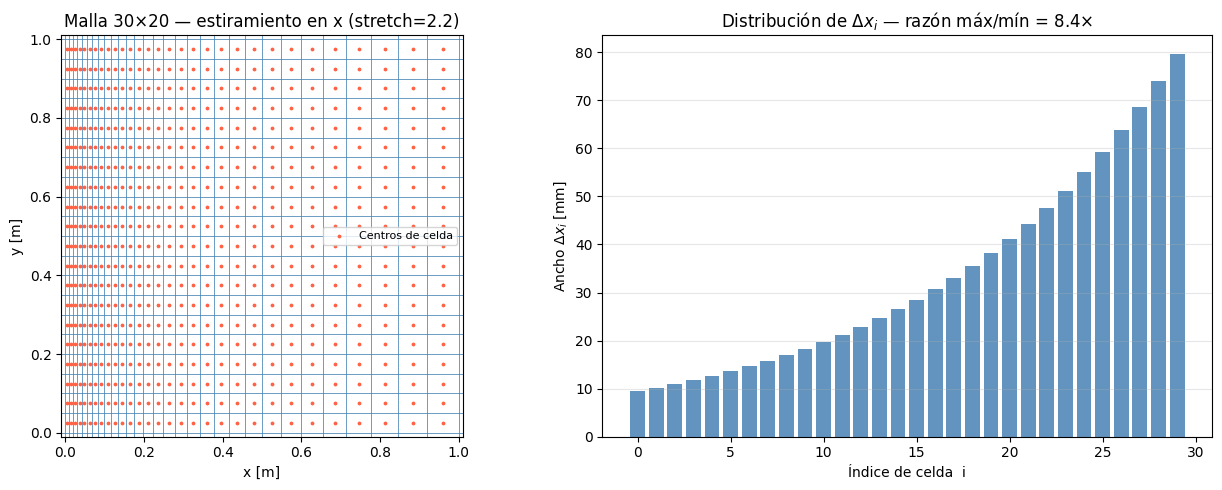

dx mínimo (i=0, cara izq) : 9.48 mm
dx máximo (i=29, cara der): 79.5 mm
Razón Δx_max / Δx_min     : 8.4×


In [278]:
stretch = 2.2   # factor de estiramiento
                # stretch=0 → uniforme; stretch=3 → celda der ≈18× más ancha que izq

s      = np.linspace(0, 1, Nx + 1)
xf     = Lx * (np.exp(stretch * s) - 1) / (np.exp(stretch) - 1)
xc     = 0.5 * (xf[:-1] + xf[1:])    # centros de celda en x
dx_arr = np.diff(xf)                   # anchos de celda

dy = Ly / Ny
y  = np.linspace(dy/2, Ly - dy/2, Ny)

X, Y = np.meshgrid(xc, y)

def idx(i, j):
    """Índice lineal de celda (i,j): k = j*Nx + i"""
    return j * Nx + i

N = Nx * Ny

# ----- Visualización de la malla -----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: líneas de la grilla
for xpos in xf:
    ax1.axvline(xpos, color='steelblue', lw=0.7, alpha=0.8)
for k in range(Ny + 1):
    ax1.axhline(k * dy, color='steelblue', lw=0.7, alpha=0.8)
ax1.scatter(X.ravel(), Y.ravel(), s=3, color='tomato', zorder=5, label='Centros de celda')
ax1.set_xlim(-0.01, Lx + 0.01);  ax1.set_ylim(-0.01, Ly + 0.01)
ax1.set_xlabel('x [m]');  ax1.set_ylabel('y [m]')
ax1.set_title(f'Malla {Nx}×{Ny} — estiramiento en x (stretch={stretch})')
ax1.set_aspect('equal');  ax1.legend(fontsize=8)

# Panel derecho: distribución de anchos Δx
ax2.bar(range(Nx), dx_arr * 1e3, color='steelblue', alpha=0.85, edgecolor='none')
ax2.set_xlabel('Índice de celda  i')
ax2.set_ylabel('Ancho $\\Delta x_i$ [mm]')
ax2.set_title(f'Distribución de $\\Delta x_i$ — razón máx/mín = {dx_arr[-1]/dx_arr[0]:.1f}×')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"dx mínimo (i=0, cara izq) : {dx_arr[0]*1e3:.2f} mm")
print(f"dx máximo (i={Nx-1}, cara der): {dx_arr[-1]*1e3:.1f} mm")
print(f"Razón Δx_max / Δx_min     : {dx_arr[-1]/dx_arr[0]:.1f}×")

## 7. Condición de Borde — Flujo con Gradiente Variable

Se extrae calor por la **mitad inferior de la cara izquierda** ($j < N_y/2$, $i = 0$).
El flujo se calcula aplicando la ley de Fourier con un gradiente prescrito variable en el tiempo:

$$q(t) = f(t) \times k_{\text{prom}}(t)$$

- **`grad_T(t)`**: gradiente de temperatura impuesto $f(t)$ [°C/m].
- **`k_prom(t)`**: conductividad efectiva promedio en las celdas de la cara activa, evaluada en $T^{(k)}$ en cada iteración de Picard.

El flujo varía aunque $f(t)$ sea constante, porque $k_{\text{prom}}$ evoluciona con la temperatura.

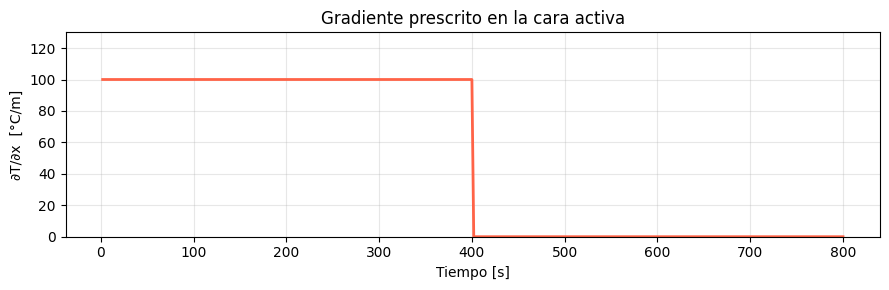

In [279]:
Nt     = int(t_end / dt)
t_arr_bc = np.linspace(dt, t_end, Nt)   # tiempos de cada paso

# ---- Gradiente prescrito en la cara activa [°C/m] ----
grad_T = np.ones(Nt)*100
grad_T[int(len(grad_T)/2):]=0

# Para señal variable, modificar directamente el array, por ejemplo:
#   grad_T[100:200] = 80.0
#   grad_T = np.interp(t_arr_bc, [0, 400, 800], [30, 70, 50])

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t_arr_bc, grad_T, color='tomato', lw=2)
ax.set_xlabel('Tiempo [s]');  ax.set_ylabel('∂T/∂x  [°C/m]')
ax.set_title('Gradiente prescrito en la cara activa')
ax.set_ylim(0, grad_T.max() * 1.3 or 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [280]:
Nt

400

## 8. Ensamble FVM

Para cada celda $(i,j)$ con índice lineal $p = j \cdot N_x + i$, la ecuación discreta (Euler implícito) es:

$$\underbrace{\frac{\rho_p c_{p,p} \,\Delta x_i \,\Delta y}{\Delta t}}_{a_P^0} \left(T_p^{n+1} - T_p^n\right) = \sum_{\text{caras}} C_f \left(T_{\text{nb}}^{n+1} - T_p^{n+1}\right) + S_{\text{BC}}$$

Los coeficientes de las caras (conductancias) usan la fórmula de **resistencias en serie**:

$$C_E = \frac{\Delta y}{\dfrac{\Delta x_i}{2 k_P} + \dfrac{\Delta x_{i+1}}{2 k_E}}, \qquad C_N = \frac{k_{\text{arm}}(k_P, k_N) \cdot \Delta x_i}{\Delta y}$$

La $k$ de cada celda se evalúa en $T^k$ (el iterado de Picard actual), lo que linealiza el sistema para esa iteración.

La BC de extracción contribuye al RHS:
$$b_p \mathrel{-}= q(t) \cdot \Delta y \quad \text{para } i=0,\; j < N_y/2$$

In [281]:
def ensamblar(T_iter, T_prev, grad_T_val):
    """
    Ensambla la matriz A y el vector b del sistema A·T^(n+1) = b.
    T_iter     : T^k  — iterado de Picard, usado para evaluar k en caras
    T_prev     : T^n  — solución del paso anterior (término transiente del RHS)
    grad_T_val : gradiente prescrito en la cara activa para este paso [°C/m]
    """
    A = lil_matrix((N, N))
    b = np.zeros(N)

    # k promedio en la cara activa (i=0, j < Ny//2), evaluada en T_iter
    k_face = np.array([k_cell(T_iter[idx(0, j)], K_BASE[j, 0]) for j in range(Ny // 2)])
    k_prom = k_face.mean()
    q_bc   = grad_T_val * k_prom   # Fourier: q = (∂T/∂x) · k  [W/m²]

    for j in range(Ny):
        for i in range(Nx):
            p    = idx(i, j)
            T_p  = T_iter[p]
            k_p  = k_cell(T_p, K_BASE[j, i])
            dx_i = dx_arr[i]

            aP   = RHO[j, i] * CP[j, i] * dx_i * dy / dt
            b[p] = aP * T_prev[p]

            # ---- Cara Este ----
            if i < Nx - 1:
                k_e  = k_cell(T_iter[idx(i+1, j)], K_BASE[j, i+1])
                coef = dy / (dx_i/(2*k_p) + dx_arr[i+1]/(2*k_e))
                A[p, idx(i+1, j)] -= coef
                aP += coef

            # ---- Cara Oeste ----
            if i > 0:
                k_w  = k_cell(T_iter[idx(i-1, j)], K_BASE[j, i-1])
                coef = dy / (dx_arr[i-1]/(2*k_w) + dx_i/(2*k_p))
                A[p, idx(i-1, j)] -= coef
                aP += coef
            elif j < Ny // 2:
                b[p] -= q_bc * dy   # extracción: q = (∂T/∂x) · k_prom
            # else: cara oeste superior → aislada

            # ---- Cara Norte ----
            if j < Ny - 1:
                k_n  = k_cell(T_iter[idx(i, j+1)], K_BASE[j+1, i])
                coef = k_harm(k_p, k_n) * dx_i / dy
                A[p, idx(i, j+1)] -= coef
                aP += coef

            # ---- Cara Sur ----
            if j > 0:
                k_s  = k_cell(T_iter[idx(i, j-1)], K_BASE[j-1, i])
                coef = k_harm(k_p, k_s) * dx_i / dy
                A[p, idx(i, j-1)] -= coef
                aP += coef

            A[p, p] = aP

    return csr_matrix(A), b

## 9. Iteración de Picard

El problema es no-lineal porque $k$ depende de $T$ (la incógnita). Se resuelve con **iteración de Picard** (también llamada *fixed-point iteration* o *substitución sucesiva*):

**Para cada paso de tiempo $n$:**
1. Inicializar: $T^{(0)} = T^n$ (usar la solución anterior como guess)
2. Repetir hasta converger:
   - Evaluar $k$ en todas las caras usando $T^{(k)}$ → ensamblar $A(T^{(k)})$
   - Resolver $A(T^{(k)}) \cdot T^{(k+1)} = b$
   - Calcular residual: $r = \|T^{(k+1)} - T^{(k)}\| / \|T^{(k+1)}\|$
   - Si $r < \text{tol}$ → converge, $T^{n+1} = T^{(k+1)}$

Si $k$ fuera constante (caso lineal), converge en **1 iteración**. Con $\gamma = -0.1$ la variación de $k$ es significativa, por lo que se necesitan más iteraciones.

## 10. Simulación

In [282]:
# Condición inicial
T = np.full(N, T0)

# Bucle de tiempo
plot_every   = max(1, Nt // n_plots)
plot_times   = []
plot_fields  = []
k_fields     = []
picard_iters = []
q_array      = []   # flujo real q(t) = (∂T/∂x)[n] · k_prom(t) [W/m²]

corner_idx = {
    'inf-izq': idx(0,    0   ),
    'inf-der': idx(Nx-1, 0   ),
    'sup-izq': idx(0,    Ny-1),
    'sup-der': idx(Nx-1, Ny-1),
}
corner_T   = {name: [] for name in corner_idx}
time_array = []

for n in range(Nt):
    t      = (n + 1) * dt
    T_prev = T.copy()
    T_iter = T.copy()

    # Iteración de Picard
    for k in range(max_iter):
        A_mat, b_vec = ensamblar(T_iter, T_prev, grad_T[n])
        T_new = spsolve(A_mat, b_vec)
        res   = np.linalg.norm(T_new - T_iter) / (np.linalg.norm(T_new) + 1e-15)
        T_iter = T_new
        if res < tol:
            break

    T = T_new
    picard_iters.append(k + 1)
    time_array.append(t)

    # flujo real con k_prom de la solución convergida
    k_face = np.array([k_cell(T[idx(0, j)], K_BASE[j, 0]) for j in range(Ny // 2)])
    q_array.append(grad_T[n] * k_face.mean())

    for name, ci in corner_idx.items():
        corner_T[name].append(T[ci])

    if (n + 1) % plot_every == 0:
        plot_times.append(t)
        plot_fields.append(T.reshape(Ny, Nx).copy())
        T_grid = T.reshape(Ny, Nx)
        k_fields.append(np.vectorize(k_cell)(T_grid, K_BASE).copy())

print(f"Simulación completa — {Nt} pasos, {t_end:.0f} s")
print(f"T_max = {T.max():.2f} °C  |  T_min = {T.min():.2f} °C")
print(f"Picard iter/paso — max: {max(picard_iters)}, promedio: {np.mean(picard_iters):.1f}")

Simulación completa — 400 pasos, 800 s
T_max = 100.00 °C  |  T_min = 94.06 °C
Picard iter/paso — max: 2, promedio: 1.7


## 11. Resultados — Campo de Temperatura

/tmp/ipykernel_8842/509024416.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


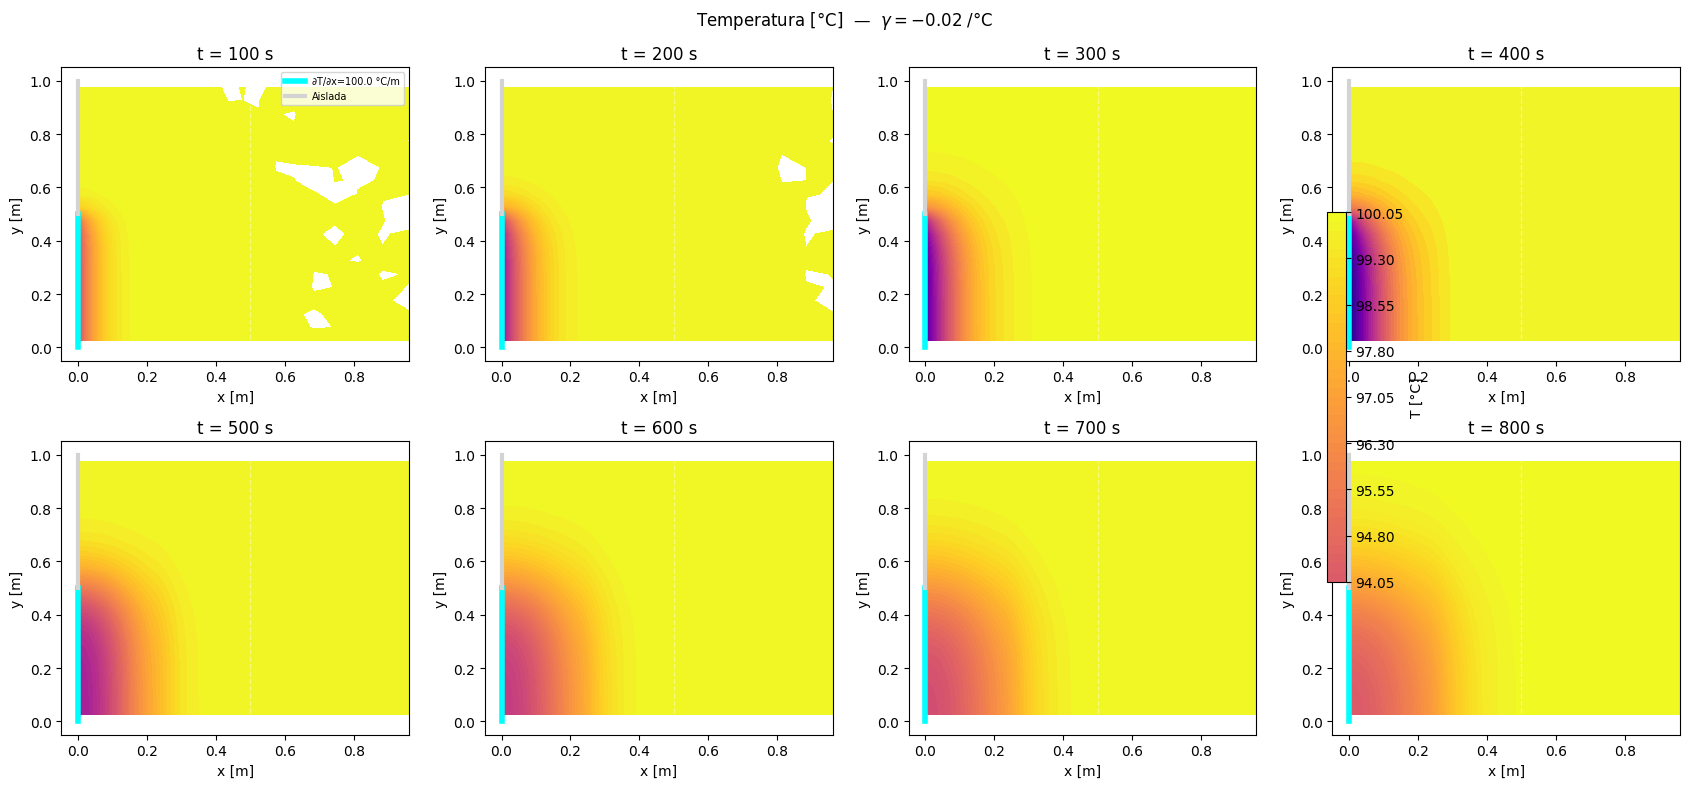

In [283]:
ncols = 4
nrows = (len(plot_times) + ncols - 1) // ncols
fig1, axes = plt.subplots(nrows, ncols, figsize=(4*ncols + 1, 4*nrows))
axes = np.array(axes).flatten()

vmin = min(f.min() for f in plot_fields)
vmax = T0

for ax in axes:
    ax.set_visible(False)

for k_p, (t_p, T_grid) in enumerate(zip(plot_times, plot_fields)):
    ax = axes[k_p]
    ax.set_visible(True)
    c = ax.contourf(X, Y, T_grid, levels=40, cmap='plasma', vmin=vmin, vmax=vmax)
    ax.set_title(f't = {t_p:.0f} s')
    ax.set_xlabel('x [m]');  ax.set_ylabel('y [m]')
    ax.axvline(Lx/2, color='white', lw=1, ls='--', alpha=0.4)
    ax.plot([0,0], [0,    Ly/2], color='cyan',      lw=4, label=f'∂T/∂x={grad_T[int(round(t_p/dt))-1]:.1f} °C/m')
    ax.plot([0,0], [Ly/2, Ly  ], color='lightgray', lw=3, label='Aislada')
    if k_p == 0:
        ax.legend(fontsize=7)

fig1.colorbar(c, ax=axes.tolist(), label='T [°C]', shrink=0.6, pad=0.02)
plt.suptitle(f'Temperatura [°C]  —  $\\gamma={gamma_k}$ /°C', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Resultados — Degradación Relativa de Conductividad $k(T)/k_0$

Este campo muestra cuánto cambió $k$ respecto a su valor inicial $k_0 = K_{\text{base}}$ (a $T = T_0$):

$$\frac{k(T)}{k_0} = \exp\!\left[\gamma\,(T - T_0)\right]$$

El ratio es independiente del material base y solo refleja el efecto de la temperatura. Valores $< 1$: $k$ bajó. Valores $> 1$: $k$ subió.

<>:22: SyntaxWarning: invalid escape sequence '\,'
<>:22: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_8842/2942073983.py:22: SyntaxWarning: invalid escape sequence '\,'
  fig2.colorbar(c2, ax=axes2.tolist(), label='$k(T)\,/\,k_0$  [—]', shrink=0.6, pad=0.02)
/tmp/ipykernel_8842/2942073983.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


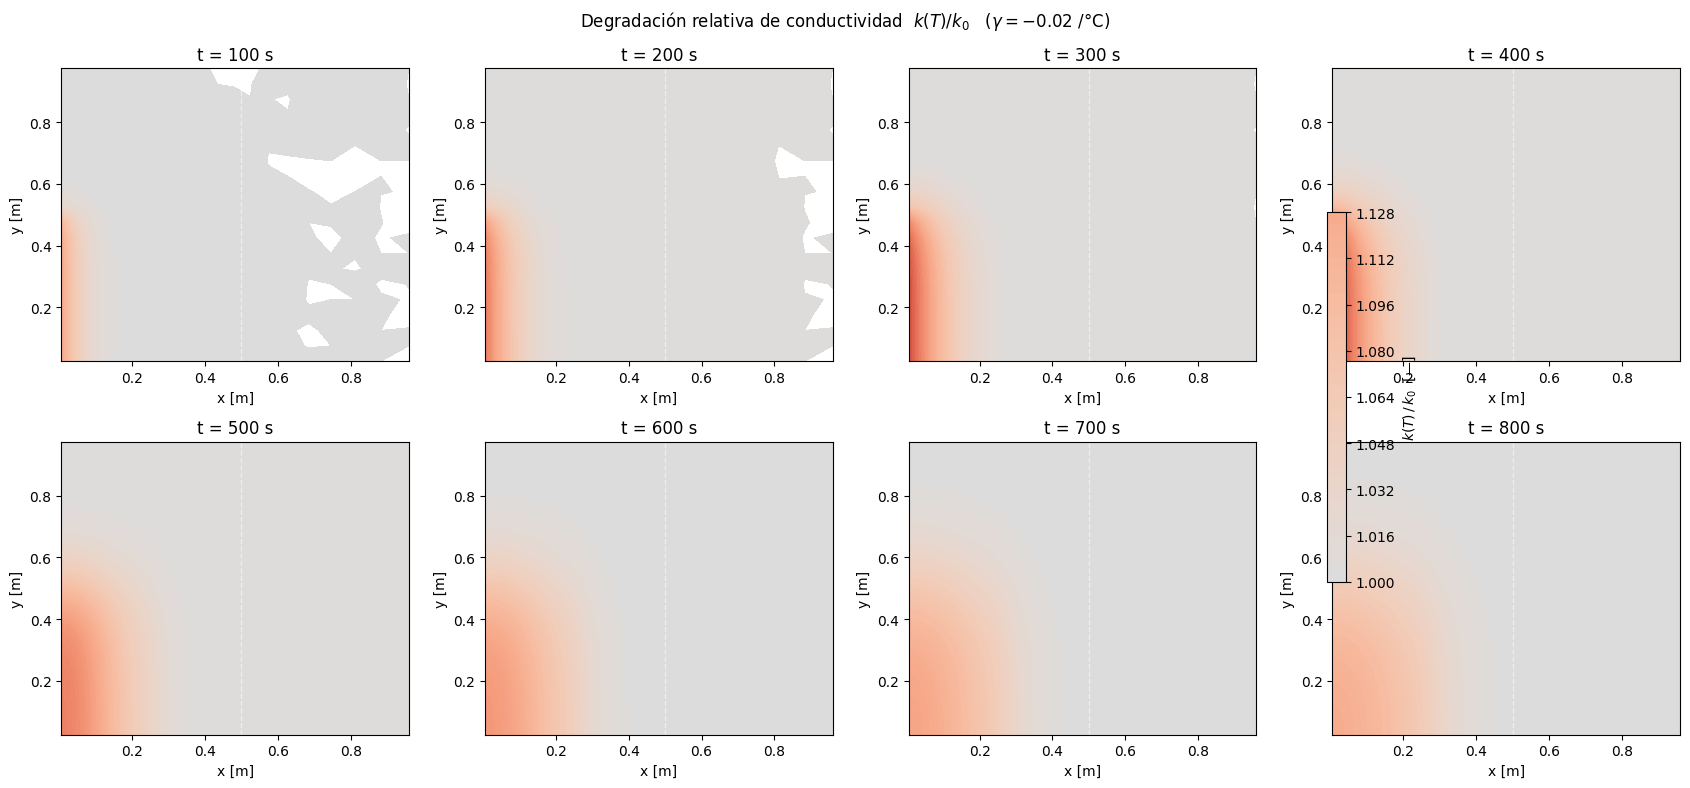

k/k0  mín = 1.0000   máx = 1.3150


In [284]:
fig2, axes2 = plt.subplots(nrows, ncols, figsize=(4*ncols + 1, 4*nrows))
axes2 = np.array(axes2).flatten()

# k/k0: ratio respecto al valor base (K_BASE a T=T0)
k_ratio_fields = [k_eff / K_BASE for k_eff in k_fields]
rmin = min(f.min() for f in k_ratio_fields)
rmax = max(f.max() for f in k_ratio_fields)
rlim = max(abs(rmin - 1.0), abs(rmax - 1.0))   # centrar colormap en 1.0

for ax in axes2:
    ax.set_visible(False)

for k_p, (t_p, k_ratio) in enumerate(zip(plot_times, k_ratio_fields)):
    ax = axes2[k_p]
    ax.set_visible(True)
    c2 = ax.contourf(X, Y, k_ratio, levels=40, cmap='coolwarm',
                     vmin=1.0 - rlim, vmax=1.0 + rlim)
    ax.set_title(f't = {t_p:.0f} s')
    ax.set_xlabel('x [m]');  ax.set_ylabel('y [m]')
    ax.axvline(Lx/2, color='white', lw=1, ls='--', alpha=0.5)

fig2.colorbar(c2, ax=axes2.tolist(), label='$k(T)\,/\,k_0$  [—]', shrink=0.6, pad=0.02)
plt.suptitle(f'Degradación relativa de conductividad  $k(T)/k_0$   ($\\gamma={gamma_k}$ /°C)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"k/k0  mín = {rmin:.4f}   máx = {rmax:.4f}")

## 13. Resultados — Series Temporales en Esquinas

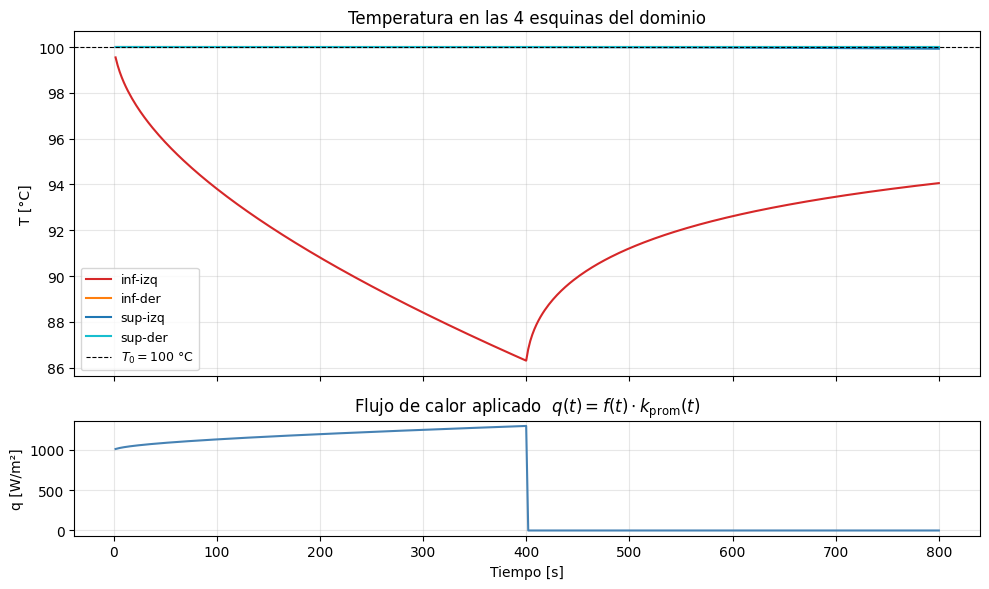


Malla en x (stretch=2.2):
  dx mínimo (cara izq) = 9.48 mm
  dx máximo (cara der) = 79.5 mm
  razón Δx_max/Δx_min  = 8.4×


In [285]:
t_arr  = np.array(time_array)
q_arr  = np.array(q_array)

fig3, (ax_T, ax_q) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1]})

colors_c = {'inf-izq': 'tab:red', 'inf-der': 'tab:orange',
             'sup-izq': 'tab:blue', 'sup-der': 'tab:cyan'}
for name, vals in corner_T.items():
    ax_T.plot(t_arr, vals, label=name, color=colors_c[name])
ax_T.axhline(T0, color='k', lw=0.8, ls='--', label=f'$T_0 = {T0:.0f}$ °C')
ax_T.set_ylabel('T [°C]')
ax_T.set_title('Temperatura en las 4 esquinas del dominio')
ax_T.legend(fontsize=9);  ax_T.grid(True, alpha=0.3)

ax_q.plot(t_arr, q_arr, color='steelblue', lw=1.5)
ax_q.set_ylabel('q [W/m²]');  ax_q.set_xlabel('Tiempo [s]')
ax_q.set_title('Flujo de calor aplicado  $q(t) = f(t) \\cdot k_{\\mathrm{prom}}(t)$')
ax_q.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMalla en x (stretch={stretch}):")
print(f"  dx mínimo (cara izq) = {dx_arr[0]*1e3:.2f} mm")
print(f"  dx máximo (cara der) = {dx_arr[-1]*1e3:.1f} mm")
print(f"  razón Δx_max/Δx_min  = {dx_arr[-1]/dx_arr[0]:.1f}×")